### Exploratory Data Analysis and Feature Engineering

In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv(r"../data/processed/neuro_natural_dataset.csv")

In [9]:
df.head()

,smiles,permeable,mol_wt,logp,h_donors,tpsa,qed,is_natural_like
0,C(=O)(OC(C)(C)C)CCCc1ccc(cc1)N(CCCl)CCCl,1.0,360.325,4.63500,0.0,29.54,0.474821,False
1,C[C@H](N)Cc1ccccc1,1.0,135.210,1.57630,1.0,26.02,0.654216,False
2,C[S](=O)(=O)c1ccc(cc1)[C@@H](O)[C@@H](CO)NC(=O...,1.0,356.227,0.40430,3.0,103.70,0.640636,False
3,CC(N)COc1c(C)cccc1C,1.0,179.263,2.02944,1.0,35.25,0.770174,False
4,c1(ccccc1)CC,1.0,106.168,2.24900,0.0,0.00,0.514758,False


In [10]:
df.tail()

,smiles,permeable,mol_wt,logp,h_donors,tpsa,qed,is_natural_like
1626,[C@H]1(NC(=O)CC1)C(=O)N2CCCCC2,1.0,196.250,0.27750,1.0,49.41,0.654463,False
1627,C1=C(N=C2[N]1C(=C(CC)C(=N2)OC)C)C3=NOC(=N3)C,1.0,273.296,1.96714,0.0,78.34,0.725583,False
1628,C1=CC=CC2=C1C3=C(C(=O)N2CCCN(C)C)C=CC=C3,1.0,280.371,3.10640,0.0,25.24,0.686126,False
1629,C3=C(C2(OC(C1CCCCN1)CO2)CC)C=CC=C3,1.0,261.365,2.80690,1.0,30.49,0.907286,False
1630,C1=C(C=CC=C1N3CCN(CCCN2C(N(C(=N2)CC)CC)=O)CC3)Cl,1.0,377.920,2.49280,0.0,46.30,0.743340,False


In [12]:
df.shape

(1631, 8)

In [14]:
# check datatypes 

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1631 entries, 0 to 1630
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   smiles           1631 non-null   object 
 1   permeable        1631 non-null   float64
 2   mol_wt           1631 non-null   float64
 3   logp             1631 non-null   float64
 4   h_donors         1631 non-null   float64
 5   tpsa             1631 non-null   float64
 6   qed              1631 non-null   float64
 7   is_natural_like  1631 non-null   bool   
dtypes: bool(1), float64(6), object(1)
memory usage: 90.9+ KB


In [17]:
# check for nulls
df.isna().sum()

smiles             0
permeable          0
mol_wt             0
logp               0
h_donors           0
tpsa               0
qed                0
is_natural_like    0
dtype: int64

In [19]:
# check for class imbalance
df["permeable"].value_counts()
df["permeable"].value_counts(normalize=True)

permeable
1.0    0.822195
0.0    0.177805
Name: proportion, dtype: float64

**Note: class imbalance present: 82% permeable, 18% impermeable, so accuracy is less important and AUC is more important**

In [20]:
# descriptive stats
df.describe()

,permeable,mol_wt,logp,h_donors,tpsa,qed
count,1631.000000,1631.000000,1631.000000,1631.000000,1631.000000,1631.000000
mean,0.822195,326.516487,2.323475,1.389945,64.143268,0.643253
std,0.382466,120.449077,2.065138,1.593313,49.318244,0.191549
min,0.000000,28.054000,-11.744600,0.000000,0.000000,0.043912
25%,1.000000,250.321500,1.307980,0.000000,32.260000,0.540170
50%,1.000000,314.860000,2.501700,1.000000,52.320000,0.689927
75%,1.000000,397.484500,3.718050,2.000000,83.510000,0.788330
max,1.000000,887.023000,10.056300,13.000000,339.590000,0.945893


In [21]:
# permeable vs non-permeable descriptive stats

df.groupby("permeable").describe().T

permeable              0.0          1.0
mol_wt   count  290.000000  1341.000000
         mean   395.488828   311.600769
         std    152.821670   106.577141
         min    109.128000    28.054000
         25%    298.673000   245.366000
         50%    389.799000   304.390000
         75%    466.022000   378.534000
         max    866.973000   887.023000
logp     count  290.000000  1341.000000
         mean     0.722375     2.669723
         std      2.703533     1.713662
         min     -8.367700   -11.744600
         25%     -0.230195     1.650400
         50%      1.029700     2.791900
         75%      2.218700     3.871400
         max      7.217600    10.056300
h_donors count  290.000000  1341.000000
         mean     3.106897     1.018643
         std      2.447855     1.009852
         min      0.000000     0.000000
         25%      1.000000     0.000000
         50%      2.000000     1.000000
         75%      4.000000     2.000000
         max     13.000000    13.000000
tpsa     count  290.000000  1341.000000
         mean   119.355931    52.203169
         std     67.295349    34.344822
         min      6.480000     0.000000
         25%     66.630000    28.600000
         50%    102.135000    46.390000
         75%    173.195000    73.130000
         max    339.590000   331.940000
qed      count  290.000000  1341.000000
         mean     0.479121     0.678747
         std      0.248383     0.155676
         min      0.043912     0.083879
         25%      0.246871     0.587967
         50%      0.497352     0.707067
         75%      0.705307     0.795100
         max      0.924384     0.945893

#### Visualizing!

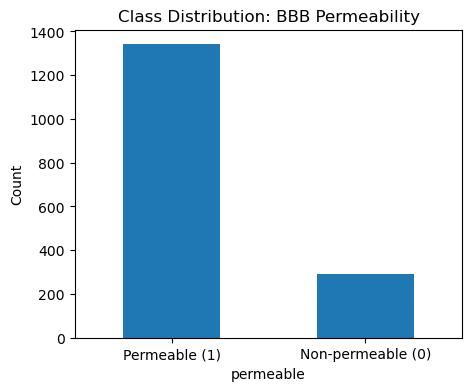

permeable
1.0    0.822195
0.0    0.177805
Name: proportion, dtype: float64

In [24]:
plt.figure(figsize=(5,4))
df['permeable'].value_counts().plot(kind='bar')
plt.xticks([1,0], ['Non-permeable (0)', 'Permeable (1)'], rotation=0)
plt.title("Class Distribution: BBB Permeability")
plt.ylabel("Count")
plt.show()

df['permeable'].value_counts(normalize=True)

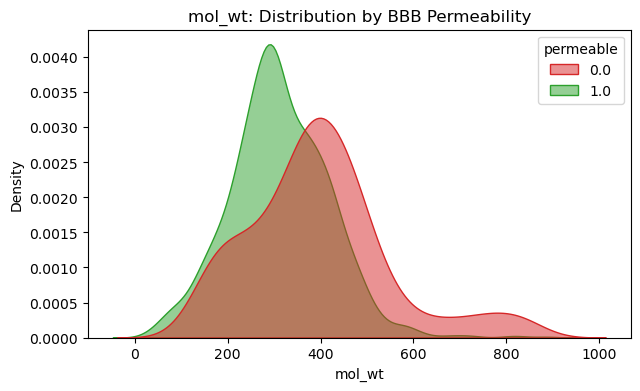

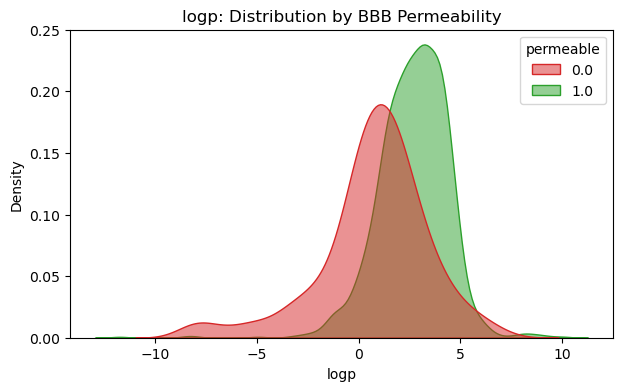

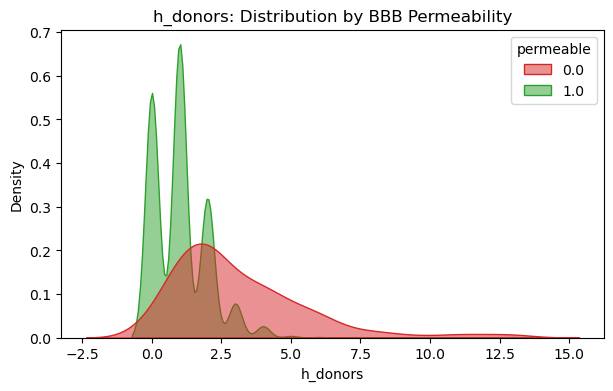

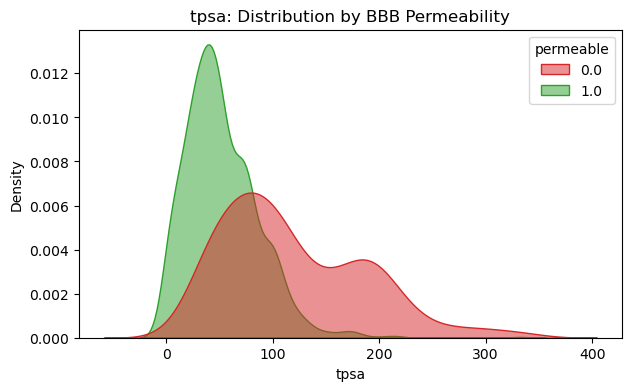

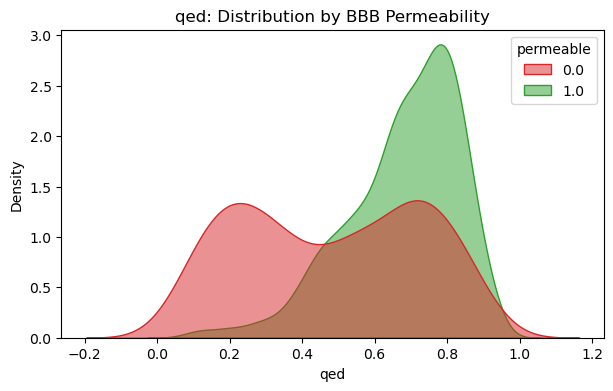

In [27]:
descriptors = ["mol_wt", "logp", "h_donors", "tpsa", "qed"]

for column in descriptors:
    plt.figure(figsize=(7,4))
    sns.kdeplot(data = df, x = column, hue = "permeable", fill = True, common_norm=False, alpha = 0.5, palette = {0:"#d62728", 1:"#2ca02c"})
    plt.title(f"{column}: Distribution by BBB Permeability")
    plt.xlabel(column)
    plt.ylabel("Density")
    plt.show()

### EDA Summary:

1. mol_wt: <400 is more permeable and >400 is less permeable, which fits common understanding
2. Lipophilicity (logP):
    - Permeable molecules are more lipophilic (mean logP = 2.67)
    - while non-permeable molecules tend to be hydrophilic (mean logP = 0.72)
    - Hydrophobicity facilitates passive diffusion across the lipid-rich BBB
3. Hydrogen Bond Donors:
   - Permeable molecules typically have 0–1 donors, whereas non-permeable molecules frequently have 2–4+ donors.
   - Excess donors increase polarity and hinder membrane permeability. The distribution supports this exactly.
4. TPSA (Topological Polar Surface Area):
    - TPSA shows the strongest separation between classes.
    - Permeable: ~52 Å²
    - Non-permeable: ~119 Å²
    - High polarity (large TPSA) correlates with poor penetration across the BBB.

5. Drug-Likeness (QED):
   - Permeable molecules show higher QED (0.68) compared to non-permeable (0.48).
   - More “optimized” compact scaffolds tend to permeate better.

**These trends are fully consistent with established CNS medicinal chemistry heuristics, validating that the dataset is chemically realistic.**

#### Distributional Analysis
1. Molecular Weight

Density plots show permeable molecules concentrated in the 250–350 Da range, while non-permeable molecules are shifted toward 350–500+ Da, with a long tail approaching 900 Da. This reinforces size as a major barrier to BBB penetration.

2. Lipophilicity (logP)

Permeable compounds cluster tightly around logP = 2–4, the optimal range for CNS penetration. Non-permeables center around logP ≈ 0–1 or even negative values, reflecting hydrophilicity and poor membrane diffusion.

3. Hydrogen Bond Donors

Permeable compounds overwhelmingly fall within 0–1 HBD, while non-permeables show a much wider spread extending to 5–8 donors. Polar functionality strongly predicts failure to cross the BBB.

4. TPSA

TPSA again shows a clear boundary: permeable molecules peak around 40–70 Å², whereas non-permeables peak around 110–150 Å². This is the most discriminative descriptor in the dataset.

5. QED

Permeable compounds show more compact, drug-like profiles (higher QED), while non-permeables include more complex, polar scaffolds that reduce drug-likeness.